In [1]:
!pip install -q numpy scipy matplotlib

C:\Users\ferna\AppData\Local\Temp\ipykernel_8976\2566223686.py:11: RuntimeWarning: invalid value encountered in sqrt
  F = 1 - A * (((np.sqrt(ys) - ys) / (ys - ys**2)) * (1 - np.sqrt(ys))**2) - x
C:\ProgramData\Anaconda3\lib\site-packages\scipy\optimize\_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
C:\Users\ferna\AppData\Local\Temp\ipykernel_8976\2566223686.py:18: RuntimeWarning: invalid value encountered in sqrt
  F = 1 - (((1 - (np.sqrt(yr)))**2) / ((1 - (np.sqrt(si)))**2)) - x


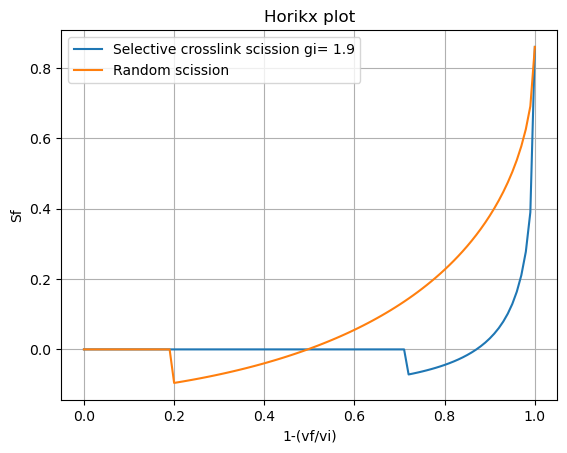

In [4]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# Definizione della funzione horikxs basata sul codice MATLAB fornito
def horikxs(ys, x):
    sip = 1.4  # frazione solubile iniziale
    si = sip / 100
    gi = ((np.sqrt(si) - si) / (si - si**2))
    A = 1 / (gi * (1 - np.sqrt(si))**2)
    F = 1 - A * (((np.sqrt(ys) - ys) / (ys - ys**2)) * (1 - np.sqrt(ys))**2) - x
    return F

# Definizione della funzione horikxr basata sul codice MATLAB fornito
def horikxr(yr, x):
    sip = 1.4  # frazione solubile iniziale
    si = sip / 100
    F = 1 - (((1 - (np.sqrt(yr)))**2) / ((1 - (np.sqrt(si)))**2)) - x
    return F

# Parametri iniziali
sip = 14  # frazione solubile iniziale
si = sip / 100

# Scissione selettiva
gi = ((np.sqrt(si) - si) / (si - si**2))
Alp = 1 / (gi * (1 - np.sqrt(si))**2)
x = np.arange(0, 1.01, 0.01)  # array da 0 a 1 con passo 0.01

# Calcolo ys e yr utilizzando la funzione fsolve
ys = np.array([fsolve(lambda ys: horikxs(ys, val), si) for val in x])
yr = np.array([fsolve(lambda yr: horikxr(yr, val), si) for val in x])

# Calcoli aggiuntivi
Ys = ys - si
Yr = yr - si

# Creazione del grafico
plt.figure()
plt.plot(x, Ys, label=f'Selective crosslink scission gi= {gi:.1f}')
plt.plot(x, Yr, label='Random scission')
plt.title('Horikx plot')
plt.xlabel('1-(vf/vi)')
plt.ylabel('Sf')
plt.grid(True)
plt.legend()
plt.show()

# Esportazione dei dati (opzionale)
# A = np.column_stack((x, Ys, Yr))
# np.savetxt('output_data.txt', A, delimiter='\t')  # Salvataggio in un file di testo